In [24]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END
from langchain_huggingface import  ChatHuggingFace,HuggingFaceEndpoint

In [25]:
from dotenv import load_dotenv
import os
load_dotenv()


True

In [26]:
HUGGINGFACEHUB_API_TOKEN = os.getenv('HUGGINGFACEHUB_API_TOKEN')

In [27]:
llm = HuggingFaceEndpoint(
    repo_id='meta-llama/Llama-3.1-8B-Instruct',
    task='text-generation',
    huggingfacehub_api_token= HUGGINGFACEHUB_API_TOKEN
)

model = ChatHuggingFace(llm = llm)

In [28]:
class BlogState(TypedDict):
    title:str
    outline:str
    blog:str
    evaluation:float

In [29]:
def generate_outline(state:BlogState)->BlogState:
    title = state['title']

    #prompt
    prompt = f'generate a detailed outline for a blog on title -{title}'

    outline = model.invoke(prompt).content

    state['outline']=outline
    return state

In [30]:
def generate_blog(state:BlogState) ->BlogState:
    title = state['title']
    outline = state['outline']

    prompt = f'Based on the outline {outline}, Generate blogs on title - {title} in structured format.'

    blog = model.invoke(prompt).content
    state['blog']=blog
    return state

In [31]:
def evaluate_blog(state:BlogState)->BlogState:
    outline = state['outline']
    blog = state['blog']

    prompt = f'Based on the {outline},evaluate the {blog}.'

    state['evaluation']= model.invoke(prompt).content

    return state

In [33]:
graph = StateGraph(BlogState)

graph.add_node('Outline',generate_outline)
graph.add_node('Blog',generate_blog)
graph.add_node('Evaluate',evaluate_blog)

graph.add_edge(START,'Outline')
graph.add_edge('Outline','Blog')
graph.add_edge('Blog','Evaluate')
graph.add_edge('Evaluate',END)

workflow = graph.compile()

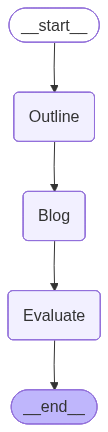

In [34]:
workflow

In [35]:
intial_state = {'title':'Journey Through Nepal'}

final_state = workflow.invoke(intial_state)

final_state

{'title': 'Journey Through Nepal',
 'outline': '**I. Introduction** \n    - Brief overview of Nepal and its attractions\n    - Importance of traveling to Nepal\n    - Brief description of the blog\n\n**II. History and Culture of Nepal**\n\n    A. Ancient History\n        - Early kingdoms and empires\n        - Hindu and Buddhist influences\n        - The rise and fall of the Malla and Shah dynasties\n\n    B. Cultural Significance\n        - Traditional festivals and celebrations\n        - Architecture, art, and handicrafts\n        - Music and dance\n\n    C. Modern Nepal\n        - Post-independence developments\n        - Economic growth and challenges\n        - Social and environmental issues\n\n**III. Must-Visit Places in Nepal**\n\n    A. Kathmandu Valley\n        - Kathmandu city\n        - Patan city\n        - Bhaktapur city\n        - Swayambhunath and Bodhnath Stupas\n        - Pashupatinath Temple\n\n    B. Pokhara and the Annapurna Region\n        - Phewa Lake and the la

In [37]:
print(final_state['outline'])

**I. Introduction** 
    - Brief overview of Nepal and its attractions
    - Importance of traveling to Nepal
    - Brief description of the blog

**II. History and Culture of Nepal**

    A. Ancient History
        - Early kingdoms and empires
        - Hindu and Buddhist influences
        - The rise and fall of the Malla and Shah dynasties

    B. Cultural Significance
        - Traditional festivals and celebrations
        - Architecture, art, and handicrafts
        - Music and dance

    C. Modern Nepal
        - Post-independence developments
        - Economic growth and challenges
        - Social and environmental issues

**III. Must-Visit Places in Nepal**

    A. Kathmandu Valley
        - Kathmandu city
        - Patan city
        - Bhaktapur city
        - Swayambhunath and Bodhnath Stupas
        - Pashupatinath Temple

    B. Pokhara and the Annapurna Region
        - Phewa Lake and the lakeside town
        - Annapurna Base Camp and trekking trails
        - Sarangko

In [38]:
print(final_state['blog'])

**Journey Through Nepal**

**I. Introduction**

Nepal, a tiny Himalayan country nestled between India and China, is a traveler's paradise. From the snow-capped peaks of the Himalayas to the lush green forests of the Terai plains, Nepal offers a diverse range of landscapes, cultures, and experiences that cater to all interests and budgets. In this blog, we'll take you on a journey through the history, culture, and must-visit places of Nepal, as well as the exciting outdoor activities and delicious food you can enjoy in this incredible country.

The importance of traveling to Nepal cannot be overstated. Not only is it a great way to experience the rich culture and history of the country, but it also provides an opportunity to contribute to the local economy and support sustainable tourism. Moreover, Nepal has been a popular destination for trekkers and adventurers for decades, and its stunning natural beauty, friendly people, and affordable prices make it an ideal destination for travele

In [39]:
print(final_state['evaluation'])

Based on the provided outline, here is the continuation of the blog post:

### C. Modern Nepal

Nepal has made significant progress in recent years, with economic growth and development projects. The country has invested heavily in infrastructure development, including roads, bridges, and airports. However, Nepal still faces various social and environmental issues, including poverty, inequality, and climate change. The country is also home to a diverse range of cultures and languages, with over 125 ethnic groups and more than 100 languages spoken.

### D. Contemporary Issues

Nepal has been affected by various contemporary issues, including the COVID-19 pandemic, which has had a significant impact on the country's economy and tourism industry. The country is also vulnerable to natural disasters, including earthquakes and floods, which can have devastating effects on the population and infrastructure. Despite these challenges, Nepal remains a resilient and resourceful nation, with a str